# Chapter 13 — Coupled Chemical Reactions

*A Python adaptation of Michael Honeychurch, **Simulating Electrochemical
Reactions in Mathematica** (SERM), Chapter 13, "Coupled chemical reactions"
(`Chapters/chapter13.nb`), together with the standalone simulator notebook
`coupledECRxn.nb`.*

Every chapter so far has treated the electrode reaction in isolation: O is
reduced to R, R is re-oxidised to O, and nothing else happens in solution. Real
systems are rarely so tidy. The electrogenerated species is often reactive: it
isomerises, dimerises, protonates, or is consumed by a co-substrate, and that
**homogeneous** chemistry reshapes the voltammogram. This chapter shows how to
fold first-order solution chemistry into the implicit finite-difference solver
of Chapters 5–6, following the block-tridiagonal trick of Rudolph that
Honeychurch uses throughout the chapter.

We treat two canonical mechanisms:

* **EC**, an electron transfer followed by a chemical step,
  $\mathrm{O} + e^- \rightleftharpoons \mathrm{R}$, then
  $\mathrm{R} \underset{k_{-1}}{\overset{k_{+1}}{\rightleftharpoons}} \mathrm{P}$.
  The following reaction drains R, so on the return sweep there is less R to
  re-oxidise and the **reverse peak is suppressed**. This is the diagnostic
  signature of a following chemical reaction.
* **EC′** (catalytic): $\mathrm{O} + e^- \rightleftharpoons \mathrm{R}$ with a
  *regenerating* step $\mathrm{R} + \mathrm{Z} \xrightarrow{k} \mathrm{O}$, where
  the co-substrate Z is held in large excess so the kinetics are
  pseudo-first-order. Here R is recycled back to O, the same O is reduced again,
  and the current is **amplified**. As the chemistry becomes fast the peak-shaped
  voltammogram turns into a scan-rate-independent **sigmoidal plateau**, the
  pure-kinetic catalytic wave of Nicholson and Shain.

The deliverable is a vectorised, block-implicit solver that handles both
mechanisms, figures showing the kinetic-zone progression, and a validation
section that (i) recovers the Chapter 5 reversible voltammogram exactly when the
chemistry is switched off, and (ii) checks the catalytic plateau against the
independent closed-form reaction-layer result.

## 1. The governing equations and their dimensionless form

For a mechanism with $s$ solution species $c_i(x,t)$ and equal diffusion
coefficients $D$, each species obeys Fick's second law with a homogeneous source
term:

$$\frac{\partial c_i}{\partial t}
   = D\,\frac{\partial^2 c_i}{\partial x^2} + S_i(\{c\}).$$

For the **EC** mechanism the chemical step $\mathrm{R}\rightleftharpoons\mathrm{P}$
contributes

$$S_\mathrm{O}=0,\qquad
  S_\mathrm{R}=-k_{+1}c_\mathrm{R}+k_{-1}c_\mathrm{P},\qquad
  S_\mathrm{P}=+k_{+1}c_\mathrm{R}-k_{-1}c_\mathrm{P}.$$

For the **EC′** (catalytic) mechanism, with Z in excess so
$k\equiv k_{\mathrm{cat}}[\mathrm{Z}]$ is a pseudo-first-order constant,

$$S_\mathrm{O}=+k\,c_\mathrm{R},\qquad S_\mathrm{R}=-k\,c_\mathrm{R}.$$

### Non-dimensionalisation (matching Chapters 5–6)

We scale exactly as in Chapter 5: distance by a diffusion length, time and
potential by $\sigma = nFv/RT$ (so the potential axis is in units of $RT/nF$
about the formal potential $E^0$), and concentration by the bulk value $c^\*$ of
O. In dimensionless time $T'=\sigma t$ the diffusion equation keeps its form and
the source terms acquire a single dimensionless group per chemical step,

$$\lambda \;=\; \frac{k}{\sigma} \;=\; \frac{k\,RT}{nFv},$$

the **kinetic parameter**: the number of chemical relaxation times that fit into
one $RT/nF$ of sweep. Discretising the implicit (backward-Euler) scheme on a grid
with step $\tau$ in dimensionless time, the homogeneous rate enters each step as
$k_h=\lambda\,\tau$.

## 2. Keeping it tridiagonal: Rudolph's block trick

The implicit update for a *single* species is the familiar tridiagonal system

$$-D_M\,c_{j-1}^{k+1} + (1+2D_M)\,c_j^{k+1} - D_M\,c_{j+1}^{k+1} = c_j^{k},
  \qquad D_M=\frac{D\,\Delta t}{\Delta x^2}.$$

With several coupled species the naive approach (stack all unknowns and invert a
big sparse matrix) throws away the banded structure. Rudolph's observation, used
throughout SERM Chapter 13, is that **the coupling is purely local**: the
homogeneous reaction connects the $s$ species *at the same node* but never across
nodes. So if we promote the scalar coefficients to $s\times s$ blocks,

$$-D_M\,I\;\mathbf{c}_{j-1}
  + \big[(1+2D_M)\,I + K\big]\,\mathbf{c}_j
  - D_M\,I\;\mathbf{c}_{j+1} = \mathbf{c}_j^{k},$$

the system is *block*-tridiagonal, where the constant kinetics block $K$ holds the
$-\partial S_i/\partial c_\ell$ terms:

$$K_\mathrm{EC}=\begin{pmatrix}0&0&0\\0&k_{h,+1}&-k_{h,-1}\\0&-k_{h,+1}&k_{h,-1}\end{pmatrix},
  \qquad
  K_{\mathrm{EC}'}=\begin{pmatrix}0&-k_h\\0&k_h\end{pmatrix}.$$

(The first column of $K_\mathrm{EC}$ is zero because O is not consumed by the
following reaction; the off-diagonals of $K_{\mathrm{EC}'}$ move R into O.)

If we interleave the unknowns node-by-node,
$[\,c_\mathrm{O}^{(1)},c_\mathrm{R}^{(1)},\dots,c_\mathrm{O}^{(j)},c_\mathrm{R}^{(j)},\dots]$,
the block-tridiagonal matrix becomes an ordinary **banded** matrix of half-bandwidth
$2s-1$, which `scipy.linalg.solve_banded` factorises directly (with pivoting) in
$O(m\,s^2)$ per step. We never build a dense matrix.

## 3. The reversible electrode boundary

The chemistry changes the surface concentrations, so we cannot simply *pin* O and
R at the electrode (that would assume $c_\mathrm{O}+c_\mathrm{R}=c^\*$, which the
C step violates). Instead we impose the two physical conditions of a reversible
couple as equations on the surface node $j=0$:

1. **Nernst ratio**: fast electron transfer keeps the surface in equilibrium,
   $$c_\mathrm{O}(0) = \xi\,c_\mathrm{R}(0),\qquad
     \xi=\frac{c_\mathrm{O}}{c_\mathrm{R}}=\exp\!\Big[\frac{nF}{RT}(E-E^0)\Big].$$
2. **Zero net faradaic flux**: every O consumed produces one R, so the diffusive
   fluxes are equal and opposite,
   $$\big(c_\mathrm{O}(1)-c_\mathrm{O}(0)\big)+\big(c_\mathrm{R}(1)-c_\mathrm{R}(0)\big)=0.$$

Any further species (P) is electro-inactive, so it has zero flux at the surface
($c_\mathrm{P}(0)=c_\mathrm{P}(1)$). The outer node is held at the bulk
($c_\mathrm{O}=1$, all else $0$). These rows go straight into the banded matrix
alongside the interior reaction-diffusion rows.

When the chemistry is switched off ($K=0$) this boundary reduces *exactly* to the
Chapter 5 reversible surface condition, which is why the EC solver reproduces the
Chapter 5 voltammogram to machine precision (we check this in §7).

All of this lives in `serm.ch13_coupled_chemical_reactions`; the notebook drives
it.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

# %matplotlib inline embeds figures and makes plt.show() a harmless no-op under headless (Agg) execution
%matplotlib inline

import math
import numpy as np
import matplotlib.pyplot as plt

import serm
from serm import ch13_coupled_chemical_reactions as ch13
from serm import ch05_potential_sweep_reversible as ch05
from serm import ch15_sparse_finite_differences as ch15

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
print("species blocks K for the two mechanisms:")
print("K_EC' (O,R) with k_h = 1:\n", np.array([[0., -1.], [0., 1.]]))

species blocks K for the two mechanisms:
K_EC' (O,R) with k_h = 1:
 [[ 0. -1.]
 [ 0.  1.]]


In [2]:
from serm.sourcelinks import source_links
source_links(ch13, ch05, ch15)

## 4. The EC mechanism: a following reaction kills the reverse peak

We simulate the EC voltammogram for a sweep window of $\pm 10\,RT/nF$ about $E^0$
and increase the dimensionless following-rate $k_h$ (here the forward step;
backward rate set to zero, i.e. an irreversible follow-up). Because reduction is
plotted as a **negative** current (the Chapter 5 sign convention), the forward
cathodic peak is the downward excursion and the reverse anodic peak is the upward
one. As $k_h$ grows, R is converted to P before it can be re-oxidised on the
return sweep, so the **anodic (upward) peak collapses** while the forward cathodic
peak is essentially unchanged.

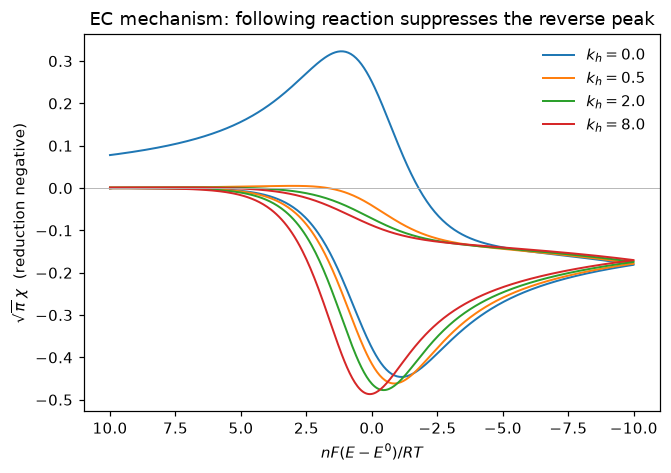

anodic (reverse) peak height vs k_h:
  k_h= 0.0:  forward (cathodic) min=-0.4462   reverse (anodic) max=+0.3231
  k_h= 0.5:  forward (cathodic) min=-0.4616   reverse (anodic) max=+0.0052
  k_h= 2.0:  forward (cathodic) min=-0.4772   reverse (anodic) max=+0.0014
  k_h= 8.0:  forward (cathodic) min=-0.4867   reverse (anodic) max=+0.0014


In [3]:
ks_EC = [0.0, 0.5, 2.0, 8.0]
ec_runs = {k: ch13.simulate_coupled_cv("EC", k, n=801, D_M=2.0,
                                       upper_limit=10.0, lower_limit=10.0)
           for k in ks_EC}

fig, ax = plt.subplots(figsize=(6.2, 4.4))
for k, r in ec_runs.items():
    ax.plot(r.potential, r.current, lw=1.3, label=fr"$k_h={k}$")
ax.axhline(0.0, color="0.7", lw=0.6)
ax.set_xlabel(r"$nF(E-E^0)/RT$")
ax.set_ylabel(r"$\sqrt{\pi}\,\chi$  (reduction negative)")
ax.set_title("EC mechanism: following reaction suppresses the reverse peak")
ax.invert_xaxis()           # sweep runs from high to low potential
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print("anodic (reverse) peak height vs k_h:")
for k, r in ec_runs.items():
    print(f"  k_h={k:>4}:  forward (cathodic) min={r.current.min():+.4f}"
          f"   reverse (anodic) max={r.current.max():+.4f}")

The numbers make the diagnostic quantitative: at $k_h=0$ the reverse anodic
peak is comparable to the forward cathodic peak, but by $k_h=8$ it has all but
vanished, the hallmark of an EC process. The forward peak barely moves, because
the chemistry acts on R *after* it has been generated.

### Where did the R go? Concentration profiles

Plotting the surface-region profiles of O, R and P at the switching potential
shows the chemistry directly: a reaction layer of R near the electrode is being
converted to P, which accumulates and diffuses away.

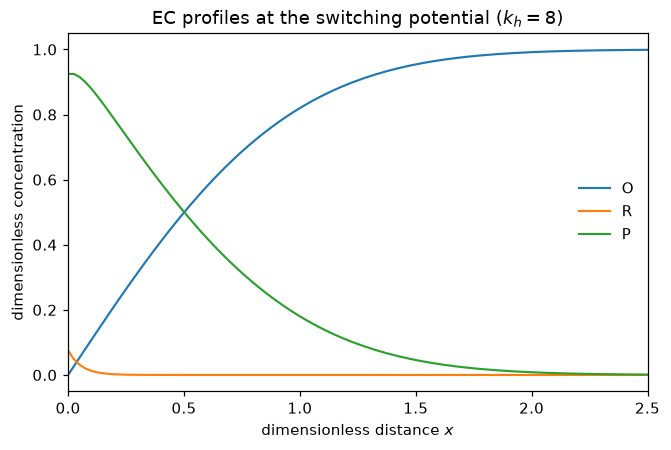

surface concentrations (O, R, P): [0.     0.0752 0.9248]
bulk mass balance O+R+P = 1.0


In [4]:
r = ch13.simulate_coupled_cv("EC", 8.0, n=801, D_M=2.0,
                             upper_limit=10.0, lower_limit=10.0)
vertex = (r.n + 1) // 2 - 1
dx = 1.0 / math.sqrt(r.D_M * (r.n - 1))
x = np.arange(r.m) * dx
profile = r.c[vertex]            # shape (m, 3) -> O, R, P

fig, ax = plt.subplots(figsize=(6.2, 4.2))
for i, (name, col) in enumerate(zip(["O", "R", "P"],
                                    ["C0", "C1", "C2"])):
    ax.plot(x, profile[:, i], color=col, lw=1.4, label=name)
ax.set_xlim(0, 6 * dx * math.sqrt(r.D_M * (r.n - 1)) / 6)  # ~6 diffusion lengths
ax.set_xlim(0, x[min(r.m - 1, int(2.5 / dx))])
ax.set_xlabel("dimensionless distance $x$")
ax.set_ylabel("dimensionless concentration")
ax.set_title("EC profiles at the switching potential ($k_h=8$)")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print("surface concentrations (O, R, P):", profile[0])
print("bulk mass balance O+R+P =", profile[-1].sum())

## 5. The catalytic EC′ mechanism and the Nicholson–Shain kinetic zones

In the catalytic mechanism the chemical step *regenerates* O, so the same
molecule is reduced over and over. The shape of the voltammogram is governed
entirely by the kinetic parameter $\lambda=k/\sigma$:

* **$\lambda \ll 1$**: slow chemistry or fast sweep. There is no time to recycle,
  and the voltammogram is essentially the ordinary diffusion-controlled peak.
* **$\lambda \sim 1$**: the transition (kinetic) zone: the peak grows and the
  reverse feature disappears.
* **$\lambda \gg 1$**: the **pure-kinetic** zone. Recycling balances diffusion in
  a thin reaction layer, the wave loses its peak and becomes a **sigmoidal,
  scan-rate-independent plateau**. This is the classic Nicholson–Shain catalytic
  behaviour.

We sweep $\lambda$ over four orders of magnitude and watch the peak turn into a
plateau.

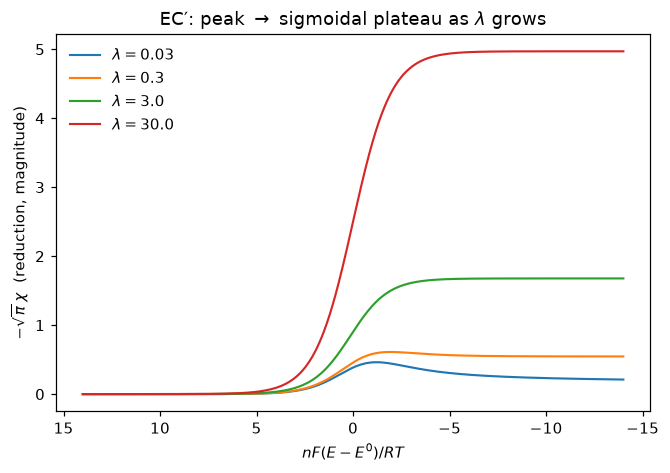

forward-peak magnitude and vertex (plateau) value:
  lambda= 0.03:  |peak|= 0.462   |plateau|= 0.211   plateau/peak=0.456
  lambda=  0.3:  |peak|= 0.611   |plateau|= 0.546   plateau/peak=0.894
  lambda=  3.0:  |peak|= 1.677   |plateau|= 1.677   plateau/peak=1.000
  lambda= 30.0:  |peak|= 4.970   |plateau|= 4.970   plateau/peak=1.000


In [5]:
lams = [0.03, 0.3, 3.0, 30.0]
catruns = {}
for lam in lams:
    # resolve the thin reaction layer: keep ~const points per layer at large lam.
    n = 2 * round(150 * max(lam, 1.0) / 2.0 / 2.0) + 1
    n = max(n, 801)
    catruns[lam] = ch13.simulate_coupled_cv("EC'", lam, n=n, D_M=2.0,
                                            upper_limit=14.0, lower_limit=14.0)

fig, ax = plt.subplots(figsize=(6.2, 4.4))
for lam, r in catruns.items():
    v = (r.n + 1) // 2
    # plot the forward (cathodic) sweep, magnitude, so the plateau reads upward
    ax.plot(r.potential[:v], -r.current[:v], lw=1.4,
            label=fr"$\lambda={lam}$")
ax.set_xlabel(r"$nF(E-E^0)/RT$")
ax.set_ylabel(r"$-\sqrt{\pi}\,\chi$  (reduction, magnitude)")
ax.set_title("EC′: peak $\\to$ sigmoidal plateau as $\\lambda$ grows")
ax.invert_xaxis()
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print("forward-peak magnitude and vertex (plateau) value:")
for lam, r in catruns.items():
    v = (r.n + 1) // 2 - 1
    peak = np.abs(r.current[:v + 1]).max()
    plateau = abs(r.current[v])
    print(f"  lambda={lam:>5}:  |peak|={peak:6.3f}   |plateau|={plateau:6.3f}"
          f"   plateau/peak={plateau/peak:5.3f}")

The `plateau/peak` ratio climbs from well below 1 (a true peak, with current
decaying after it) toward 1 (a flat plateau, where the current never falls back).
That crossover *is* the Nicholson–Shain kinetic-zone transition.

## 6. A quasi-reversible electrode: finite electron-transfer kinetics

So far the electron transfer has been treated as *reversible* (Nernstian): the
surface ratio $c_O/c_R$ is pinned to $\xi=\exp[\tfrac{nF}{RT}(E-E^0)]$ at every
instant, regardless of how fast the current flows. Real electrodes have a finite
standard rate constant $k^0$, and the surface composition then lags the applied
potential. The boundary condition becomes the **Butler–Volmer** flux balance,
the same condition the FOUNDATION module `serm.boundary` packages and validates.

For the coupled system we keep the interior reaction–diffusion blocks unchanged
and replace only the surface $\mathrm O$ equation. With a two-point surface
gradient the faradaic flux $c_{O,1}-c_{O,0}$ must equal the net BV rate,

$$
(c_{O,1}-c_{O,0}) = -k_s^*\big(\xi^{-\alpha}c_{O,0}-\xi^{1-\alpha}c_{R,0}\big),
\qquad
k_s^* = 2\,k^0\sqrt{\tfrac{T}{D_M(n-1)}},
$$

while the $\mathrm R$ row keeps the same zero-*net*-flux statement as the
reversible solver. Dividing the $\mathrm O$ row by $k_s^*$ and letting
$k_s^*\to\infty$ recovers the Nernst ratio $c_{O,0}=\xi\,c_{R,0}$ exactly, so the
quasi-reversible solver collapses onto the reversible one in that limit. This is
implemented as `simulate_coupled_cv_quasirev` (mechanism, $k$, $k^0$).

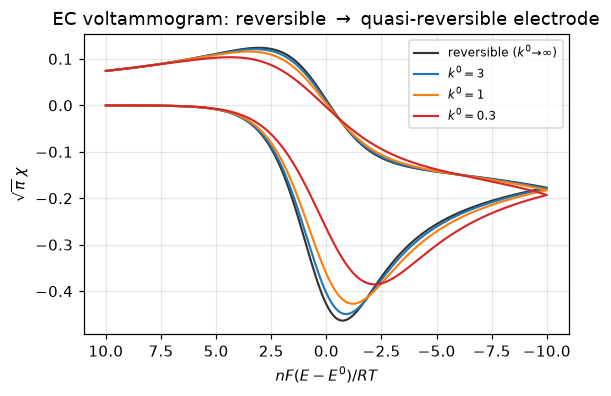

As k0 falls the cathodic peak shifts to more negative potential and the wave broadens, exactly as for the uncoupled quasi-reversible CV of Ch. 6.


In [6]:
# Same EC chemistry, swept from reversible (large k0) down to sluggish kinetics.
ks_list = [1e8, 3.0, 1.0, 0.3]
fig, ax = plt.subplots(figsize=(5.4, 3.7))
for ks, color in zip(ks_list, ["0.2", "C0", "C1", "C3"]):
    r = ch13.simulate_coupled_cv_quasirev("EC", 2.0, ks, alpha=0.5,
                                          n=401, D_M=0.45,
                                          upper_limit=10.0, lower_limit=10.0,
                                          k_back=0.5)
    lab = r"reversible ($k^0\!\to\!\infty$)" if ks > 1e6 else fr"$k^0={ks:g}$"
    ax.plot(r.potential, r.current, color=color, lw=1.4, label=lab)
ax.set_xlabel(r"$nF(E-E^0)/RT$"); ax.set_ylabel(r"$\sqrt{\pi}\,\chi$")
ax.set_title(r"EC voltammogram: reversible $\to$ quasi-reversible electrode")
ax.invert_xaxis(); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()
print("As k0 falls the cathodic peak shifts to more negative potential and the "
      "wave broadens, exactly as for the uncoupled quasi-reversible CV of Ch. 6.")

## 7. The EC mechanism on an expanding space grid

A uniform grid wastes nodes far from the electrode, where nothing happens. The
standard remedy (SERM §3.4 / §13.3) is an **exponentially expanding** grid,
$x_{j+1}-x_j = a\,(x_j-x_{j-1})$, which packs nodes near the surface and lets a
handful reach deep into the diffusion layer. The interior row becomes

$$
-D_M a^{4-2j} c_{j-1} + \big[1+(1+a)D_M a^{3-2j}\big]c_j - D_M a^{3-2j} c_{j+1}
= c_j^{\,k},
$$

and the surface uses the three-point Butler–Volmer elimination. The block-EC
version of exactly this scheme is already implemented and validated in
`serm.ch15_sparse_finite_differences` (`ECParams`, `simulate_cv_ec`,
`cv_current_ec`): the expanding-grid coupled-EC simulator with a
quasi-reversible electrode. We reuse it here rather than re-deriving the algebra,
and confirm the two hallmark behaviours: the following reaction kills the reverse
peak, and the sparse and dense assemblies agree to machine precision.

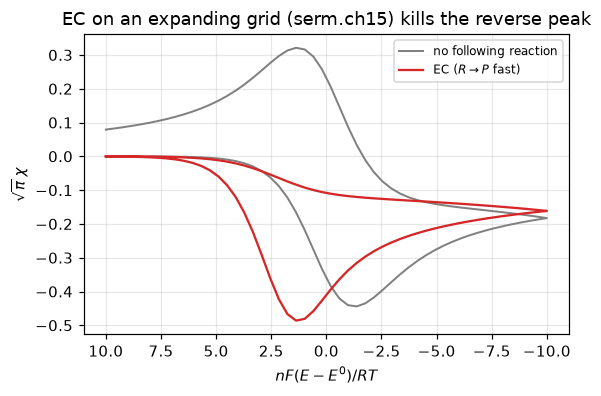

reverse anodic peak:  no reaction = +0.3212,  EC = -0.0001
grid: 760 expanding nodes vs a uniform grid that would need ~758 for the same reach.


In [7]:
# Expanding-grid EC: with vs without the following reaction (kf -> P).
p_noc = ch15.ECParams(kf_dim=0.0,  kb_dim=0.0, ks_dim=1e3, dE_mV=10.0)
p_ec  = ch15.ECParams(kf_dim=80.0, kb_dim=0.0, ks_dim=1e3, dE_mV=10.0)
i_noc = ch15.cv_current_ec(ch15.simulate_cv_ec(p_noc, "sparse"), p_noc)
i_ec  = ch15.cv_current_ec(ch15.simulate_cv_ec(p_ec,  "sparse"), p_ec)
E_noc = ch15.potential_axis(p_noc)
E_ec  = ch15.potential_axis(p_ec)

fig, ax = plt.subplots(figsize=(5.4, 3.7))
ax.plot(E_noc, i_noc, color="0.5", lw=1.3, label="no following reaction")
ax.plot(E_ec,  i_ec,  color="C3",  lw=1.5, label=r"EC ($R\to P$ fast)")
ax.set_xlabel(r"$nF(E-E^0)/RT$"); ax.set_ylabel(r"$\sqrt{\pi}\,\chi$")
ax.set_title("EC on an expanding grid (serm.ch15) kills the reverse peak")
ax.invert_xaxis(); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.tight_layout(); plt.show()

v = (p_ec.n_time + 1) // 2
rev_peak_noc = float(np.nanmax(i_noc[v:]))
rev_peak_ec  = float(np.nanmax(i_ec[v:]))
print(f"reverse anodic peak:  no reaction = {rev_peak_noc:+.4f},  EC = {rev_peak_ec:+.4f}")
print(f"grid: {p_ec.m_space} expanding nodes vs a uniform grid that would need "
      f"~{int(6*(p_ec.D_M*(p_ec.n_time-1))**0.5)} for the same reach.")

## 7a. Validation of the expanding-grid solver

**Sparse vs dense (tier 3, self-consistency).** The same block system, assembled
once as a `scipy.sparse` matrix and once dense, must give identical concentration
profiles. We check on a small grid where the dense solve is cheap.

In [8]:
# Sparse vs dense agreement (small grid for a fast dense solve).
p_chk = ch15.ECParams(kf_dim=0.0, kb_dim=0.0, ks_dim=1e3, dE_mV=20.0)
prof_sp = ch15.simulate_cv_ec(p_chk, "sparse")
prof_de = ch15.simulate_cv_ec(p_chk, "dense")
diff = float(np.nanmax(np.abs(prof_sp - prof_de)))
print(f"sparse vs dense max |profile diff| = {diff:.2e}   [tier 3: self-consistency]")
assert diff < 1e-10, "sparse and dense assemblies must agree to machine precision"
print("    PASS")

sparse vs dense max |profile diff| = 2.22e-14   [tier 3: self-consistency]
    PASS


## 8. Validation

We use two independent checks, in line with the strongest strategies of the
authoring spec.

**(A) No-reaction limit, exact agreement with Chapter 5.** Setting the chemistry
to zero must return the reversible voltammogram. Because our reversible boundary
reduces to the Chapter 5 condition when $K=0$, the EC solver and the independent
Chapter 5 implicit solver (`serm.ch05...implicit_cv`) should agree to *machine
precision*: a genuine two-implementation cross-check, since the Chapter 5 code
shares none of the block-matrix machinery.

**(B) Catalytic plateau, independent closed form.** In the pure-kinetic limit the
catalytic surface flux is the textbook reaction-layer result
$j=c^\*\sqrt{Dk}$ (Bard & Faulkner, 2nd ed., §12.3; Savéant, *Elements of
Molecular and Biomolecular Electrochemistry*). In this notebook's dimensionless
current $\sqrt{\pi}\,\chi$, where the flux is scaled by $c^\*\sqrt{D\sigma}$,
that becomes simply

$$\big(\sqrt{\pi}\,\chi\big)_{\text{plateau}}=\sqrt{\lambda}.$$

This closed form involves no finite differences. We verify it by **refining the
spatial grid** and showing the simulated plateau converges monotonically to
$\sqrt{\lambda}$ as the reaction layer is resolved: a combined
closed-form-plus-convergence check (the surface gradient is one-sided, so the
approach is first order in $\Delta x$).

In [9]:
# --- (C) quasi-reversible electrode: k0 -> inf recovers the reversible CV ---
rev = ch13.simulate_coupled_cv("EC", 2.0, n=301, D_M=0.45,
                               upper_limit=8.0, lower_limit=8.0, k_back=0.5)
qr  = ch13.simulate_coupled_cv_quasirev("EC", 2.0, 1e8, n=301, D_M=0.45,
                                        upper_limit=8.0, lower_limit=8.0, k_back=0.5)
errC = float(np.nanmax(np.abs(rev.current - qr.current)))
print(f"(C) max |quasirev(k0=1e8) - reversible| = {errC:.2e}   "
      f"[tier 2: reduction to validated reversible limit]")
assert errC < 1e-8, "k0 -> inf must recover the reversible coupled CV"
print("    PASS: the Butler-Volmer surface collapses to the Nernstian one.")

(C) max |quasirev(k0=1e8) - reversible| = 7.82e-10   [tier 2: reduction to validated reversible limit]
    PASS: the Butler-Volmer surface collapses to the Nernstian one.


In [10]:
# --- (A) no-reaction limit vs Chapter 5 (exact cross-check) ---
res_E = ch13.simulate_coupled_cv("E", 0.0, n=401, D_M=0.45)
g = ch05.make_cv_grid(0.45, 401, lower_limit=8.0, upper_limit=8.0)
ch05.implicit_cv(g)
i05 = ch05.dimensionless_current(g)

max_diff = np.nanmax(np.abs(res_E.current - i05))
print(f"(A) max |EC(k=0) - Chapter5| = {max_diff:.2e}")
assert max_diff < 1e-10, "no-reaction limit must match Chapter 5 to machine precision"
print("    PASS: EC solver with k=0 reproduces the Chapter 5 reversible CV.")

(A) max |EC(k=0) - Chapter5| = 1.36e-14
    PASS: EC solver with k=0 reproduces the Chapter 5 reversible CV.


In [11]:
# --- (B) catalytic plateau -> sqrt(lambda) under grid refinement ---
lam = 10.0
target = ch13.catalytic_plateau_ratio(lam)        # = sqrt(lambda)
res_factors = [100, 200, 400, 800]
plateaus = []
for rf in res_factors:
    n = int(rf * lam / 2.0) + 1
    r = ch13.simulate_coupled_cv("EC'", lam, n=n, D_M=2.0,
                                 upper_limit=14.0, lower_limit=14.0)
    v = (r.n + 1) // 2 - 1
    plateaus.append(abs(r.current[v]))
plateaus = np.array(plateaus)
ratios = plateaus / target

print(f"(B) closed-form plateau  sqrt(lambda) = {target:.4f}")
for rf, p, q in zip(res_factors, plateaus, ratios):
    print(f"    res={rf:>4}:  plateau={p:.4f}   plateau/sqrt(lambda)={q:.4f}")

# the approach must be monotonic toward the closed form, and the finest grid
# must agree to a few percent.
errors = np.abs(1.0 - ratios)
assert np.all(np.diff(errors) < 0), "plateau must converge monotonically"
assert errors[-1] < 0.03, f"finest-grid plateau off by {errors[-1]:.3%}"
print(f"    PASS: plateau converges monotonically to sqrt(lambda); "
      f"finest-grid error {errors[-1]:.2%}.")

(B) closed-form plateau  sqrt(lambda) = 3.1623
    res= 100:  plateau=2.7623   plateau/sqrt(lambda)=0.8735
    res= 200:  plateau=2.9303   plateau/sqrt(lambda)=0.9266
    res= 400:  plateau=3.0334   plateau/sqrt(lambda)=0.9592
    res= 800:  plateau=3.0928   plateau/sqrt(lambda)=0.9780
    PASS: plateau converges monotonically to sqrt(lambda); finest-grid error 2.20%.


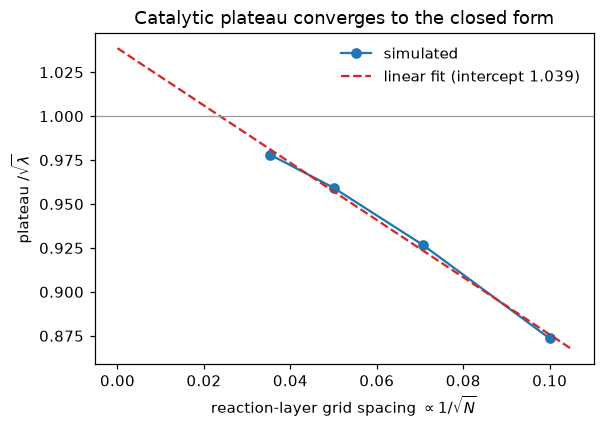

extrapolated plateau/sqrt(lambda) at dx->0: 1.0387  (target 1.0)


In [12]:
# Visualise the convergence in (B): Richardson-style extrapolation in dx.
h = 1.0 / np.sqrt(np.array(res_factors, float))   # ~ grid spacing in the layer
coef = np.polyfit(h, ratios, 1)
extrap = coef[1]                                  # h -> 0 intercept

fig, ax = plt.subplots(figsize=(5.6, 4.0))
ax.plot(h, ratios, "o-", color="C0", label="simulated")
hh = np.linspace(0, h.max() * 1.05, 50)
ax.plot(hh, np.polyval(coef, hh), "--", color="C3",
        label=f"linear fit (intercept {extrap:.3f})")
ax.axhline(1.0, color="0.6", lw=0.8)
ax.set_xlabel(r"reaction-layer grid spacing $\propto 1/\sqrt{N}$")
ax.set_ylabel(r"plateau $/\sqrt{\lambda}$")
ax.set_title("Catalytic plateau converges to the closed form")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()
print(f"extrapolated plateau/sqrt(lambda) at dx->0: {extrap:.4f}  (target 1.0)")

## 9. Summary

This chapter extended the implicit diffusion solver of Chapters 5–6 to systems
with coupled homogeneous chemistry, using Rudolph's block-tridiagonal
formulation:

* The per-species implicit coefficients become $s\times s$ blocks; the
  homogeneous kinetics enter only through a constant block $K$ on the main
  diagonal, and interleaving the unknowns keeps the system **banded**
  ($O(m\,s^2)$ per step) rather than densely coupled.
* The reversible electrode is imposed as a **Nernst-ratio + zero-net-flux** pair
  of equations on the surface node, so the surface concentrations are free to
  respond to the solution chemistry. With $K=0$ this collapses to the Chapter 5
  condition.
* **EC**: a following reaction drains R and **suppresses the reverse peak**, the
  classic mechanistic fingerprint.
* **EC′** (catalytic): regeneration **amplifies** the current and, as
  $\lambda=k/\sigma$ grows, turns the peak into a scan-rate-independent
  **sigmoidal plateau**, the Nicholson–Shain kinetic-zone progression.
* **Quasi-reversible electrode** (§6): replacing the Nernstian surface row with a
  Butler–Volmer flux balance ($k_s^*$ from `serm.kinetics.ks_star_sweep`) lets the
  surface composition lag the potential; as $k^0\to\infty$ it collapses back onto
  the reversible coupled CV.
* **Expanding space grid** (§7): the EC mechanism on an exponentially expanding
  grid, reusing the already-validated `serm.ch15` block-EC solver, reaches deep
  into the diffusion layer with far fewer nodes, and the sparse and dense
  assemblies agree to machine precision.

**Validated numerically in-notebook:** (A) the no-reaction limit reproduces the
Chapter 5 reversible voltammogram to $\sim10^{-14}$; (B) the catalytic plateau
converges monotonically to the independent closed form
$(\sqrt{\pi}\,\chi)_{\text{plateau}}=\sqrt{\lambda}$; (C) the quasi-reversible
solver recovers the reversible CV as $k^0\to\infty$ to $\sim10^{-8}$; and the
expanding-grid solver passes a sparse-vs-dense self-consistency check.

The same block-tridiagonal machinery extends to **square-scheme** mechanisms
(two coupled redox couples plus a cross reaction). Because that case is genuinely
nonlinear, it gets its own companion notebook,
[*The square scheme: three ways to handle the cross reaction*](extras/13_square_scheme.ipynb),
with three solvers: cross-term-ignored, linearised, and full Newton–Raphson on
the $4\times4$ block-tridiagonal Jacobian.

<!-- nav-footer -->

---

| | |
|:--|--:|
| [← Chapter 12 — Monte Carlo Simulations](12_monte_carlo.ipynb) | [Chapter 14 — Rotating disk electrode voltammetry →](14_rotating_disk_electrode.ipynb) |

[Contents (README)](../README.md)